# Comparação entre simulação OpenDSS Puro e Co-simulação Mosaik

O sistema utilizado em estudo consiste no sistema de 123 barras do IEEE.

Entre as condiçõos o qual simulações foram performadas, destaca-se

- Controle dos reguladores de tensão desabilitados
- Modo de controle = Time
- Simulação de 24 horas ao passo de 5 minutos

O comparativo analisa os resultados do comportamento deste sistema na com e sem presenção de um sistema fotovoltaico, a saber o elemento PVSystem utilizado é

```bash
New PVSystem.PV phases=3 Bus1=680 kV=4.16 kVA=1000 irrad=0.8 Pmpp=1000
~ temperature=25 PF=1 EffCurve=MyEff P-TCurve=MyPvsT
~ Daily=my_shape2_pv TDaily=MyTemp
~ Vminpu=0.001
~ Model=1
```

Por fim, utiliza-se uma métrica de rmse e mae para analisar a diferença entre as grandezas obtidas por opendss puro e co-simulação mosaik

## Dominio do OpenDSS puro

In [ ]:
# Standard library
import os
from pathlib import Path
import math
from collections import defaultdict
import re
import random
from tqdm import tqdm
import datetime as dt

# Third-party
import py_dss_interface
from simulators.api_opendss import OpenDSS
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [2]:
BASE_DIR = Path("..").resolve()
BASE_DIR

PosixPath('/mnt/c/Users/pvict/documents/UFC/GREI/GREI_Projeto_OpenTES/tsre/tsre-der-opentes/src')

In [3]:
dss = py_dss_interface.DSS()


In [18]:
DSS_FILE = BASE_DIR / 'data' / '13Bus' / 'run_ieee13_cosim_pv_5min.dss'

dss.text('Clear')
dss.text(f"Compile '{DSS_FILE}'")
dss.text("Solve")

dss.circuit.set_active_bus('650')
kv_650 = dss.bus.kv_base * 1000

dss.monitors.name = 'feeder_output_vi'

l650632_va_mag_pv = [v/kv_650 for v in dss.monitors.channel(1)]
l650632_vb_mag_pv = [v/kv_650 for v in dss.monitors.channel(3)]
l650632_vc_mag_pv = [v/kv_650 for v in dss.monitors.channel(5)]

dss.monitors.name = 'feeder_output_pq'

l650632_pa_pv = dss.monitors.channel(1)
l650632_qa_pv = dss.monitors.channel(2)
l650632_pb_pv = dss.monitors.channel(3)
l650632_qb_pv = dss.monitors.channel(4)
l650632_pc_pv = dss.monitors.channel(5)
l650632_qc_pv = dss.monitors.channel(6)

dss.circuit.set_active_bus('680')
kv_680 = dss.bus.kv_base * 1000

dss.monitors.name = 'Line671680_vi'
bus680_va_pv = [v/kv_680 for v in dss.monitors.channel(1)]
bus680_vb_pv = [v/kv_680 for v in dss.monitors.channel(3)]
bus680_vc_pv = [v/kv_680 for v in dss.monitors.channel(5)]

dss.monitors.name = 'Line671680_pq'
bus680_pa_pv = dss.monitors.channel(1)
bus680_qa_pv = dss.monitors.channel(2)
bus680_pb_pv = dss.monitors.channel(3)
bus680_qb_pv = dss.monitors.channel(4)
bus680_pc_pv = dss.monitors.channel(5)
bus680_qc_pv = dss.monitors.channel(6)

dss.circuit.set_active_bus('611')
kv_611 = dss.bus.kv_base * 1000

dss.monitors.name = 'Line684611_vi'
# Apenas a fase C existe (canal 1). Fases A e B são zeros.
tamanho = len(dss.monitors.channel(1))
bus611_va_pv = [0.0] * tamanho
bus611_vb_pv = [0.0] * tamanho
bus611_vc_pv = [v/kv_611 for v in dss.monitors.channel(1)]

dss.monitors.name = 'Line684611_pq'
# O monitor de potência de um elemento monofásico só tem valores nos canais 1 e 2 (P e Q da fase única, que é a fase C)
# Os demais canais (3,4,5,6) não existem ou são zero. Vamos criar zeros explícitos para as fases A e B.
potencia_tamanho = len(dss.monitors.channel(1))  # mesmo tamanho do canal 1
bus611_pa_pv = [0.0] * potencia_tamanho
bus611_qa_pv = [0.0] * potencia_tamanho
bus611_pb_pv = [0.0] * potencia_tamanho
bus611_qb_pv = [0.0] * potencia_tamanho
bus611_pc_pv = dss.monitors.channel(1)   # Potência ativa da fase C
bus611_qc_pv = dss.monitors.channel(2)   # Potência reativa da fase C

Actor 1 terminated
>>Waiting...
Actor 1: Job done
>>

## Co-simulação Mosaik

### *Sem Volt-Var:*

In [ ]:
df_cosim_pv = pd.read_csv(BASE_DIR / 'output' / 'result_run_ieee13_cosim_smart_pv_5min.csv')

# Tensões
l650632_va_mag_pv_cosim = df_cosim_pv['DSS-0.Bus-650-V1_pu']
l650632_vb_mag_pv_cosim = df_cosim_pv['DSS-0.Bus-650-V2_pu']
l650632_vc_mag_pv_cosim = df_cosim_pv['DSS-0.Bus-650-V3_pu']

bus680_va_pv_cosim = df_cosim_pv['DSS-0.Bus-680-V1_pu']
bus680_vb_pv_cosim = df_cosim_pv['DSS-0.Bus-680-V2_pu']
bus680_vc_pv_cosim = df_cosim_pv['DSS-0.Bus-680-V3_pu']

bus611_va_pv_cosim = df_cosim_pv['DSS-0.Bus-611-V1_pu']
bus611_vb_pv_cosim = df_cosim_pv['DSS-0.Bus-611-V2_pu']
bus611_vc_pv_cosim = df_cosim_pv['DSS-0.Bus-611-V3_pu']

# Potências da linha 650632 (feeder)
l650632_pa_pv_cosim = df_cosim_pv['DSS-0.Line-650632-P1_w']
l650632_qa_pv_cosim = df_cosim_pv['DSS-0.Line-650632-Q1_var']
l650632_pb_pv_cosim = df_cosim_pv['DSS-0.Line-650632-P2_w']
l650632_qb_pv_cosim = df_cosim_pv['DSS-0.Line-650632-Q2_var']
l650632_pc_pv_cosim = df_cosim_pv['DSS-0.Line-650632-P3_w']
l650632_qc_pv_cosim = df_cosim_pv['DSS-0.Line-650632-Q3_var']

# Potências da linha 671680
bus680_pa_pv_cosim = df_cosim_pv['DSS-0.Line-671680-P1_w']
bus680_qa_pv_cosim = df_cosim_pv['DSS-0.Line-671680-Q1_var']
bus680_pb_pv_cosim = df_cosim_pv['DSS-0.Line-671680-P2_w']
bus680_qb_pv_cosim = df_cosim_pv['DSS-0.Line-671680-Q2_var']
bus680_pc_pv_cosim = df_cosim_pv['DSS-0.Line-671680-P3_w']
bus680_qc_pv_cosim = df_cosim_pv['DSS-0.Line-671680-Q3_var']

# Potências da linha 684611
bus611_pa_pv_cosim = df_cosim_pv['DSS-0.Line-684611-P1_w']
bus611_qa_pv_cosim = df_cosim_pv['DSS-0.Line-684611-Q1_var']
bus611_pb_pv_cosim = df_cosim_pv['DSS-0.Line-684611-P2_w']
bus611_qb_pv_cosim = df_cosim_pv['DSS-0.Line-684611-Q2_var']
bus611_pc_pv_cosim = df_cosim_pv['DSS-0.Line-684611-P3_w']
bus611_qc_pv_cosim = df_cosim_pv['DSS-0.Line-684611-Q3_var']

# Temperatura, irradiação e potência DC/AC 
temperature_cosim = df_cosim_pv['PVSimulator-0.PVPanel_0-temperature']
irradiance_cosim = df_cosim_pv['PVSimulator-0.PVPanel_0-irradiance']
pv_dc_cosim = df_cosim_pv['PVSimulator-0.PVPanel_0-P_dc']
inv_pac_cosim = df_cosim_pv['DSS-0.PVSystem-pv-P_meas']

### *Com Volt-Var:*

In [6]:
# Carrega o arquivo com controle Volt-Var
df_cosim_pv_voltvar = pd.read_csv(BASE_DIR / 'output' / 'result_run_ieee13_cosim_smart_pv_5min_voltvar.csv')

# Tensões (com sufixo _voltvar)
l650632_va_mag_pv_voltvar = df_cosim_pv_voltvar['DSS-0.Bus-650-V1_pu']
l650632_vb_mag_pv_voltvar = df_cosim_pv_voltvar['DSS-0.Bus-650-V2_pu']
l650632_vc_mag_pv_voltvar = df_cosim_pv_voltvar['DSS-0.Bus-650-V3_pu']

bus680_va_pv_voltvar = df_cosim_pv_voltvar['DSS-0.Bus-680-V1_pu']
bus680_vb_pv_voltvar = df_cosim_pv_voltvar['DSS-0.Bus-680-V2_pu']
bus680_vc_pv_voltvar = df_cosim_pv_voltvar['DSS-0.Bus-680-V3_pu']

bus611_va_pv_voltvar = df_cosim_pv_voltvar['DSS-0.Bus-611-V1_pu']
bus611_vb_pv_voltvar = df_cosim_pv_voltvar['DSS-0.Bus-611-V2_pu']
bus611_vc_pv_voltvar = df_cosim_pv_voltvar['DSS-0.Bus-611-V3_pu']

# Potências da linha 650632 (feeder) - VoltVar
l650632_pa_pv_voltvar = df_cosim_pv_voltvar['DSS-0.Line-650632-P1_w']
l650632_qa_pv_voltvar = df_cosim_pv_voltvar['DSS-0.Line-650632-Q1_var']
l650632_pb_pv_voltvar = df_cosim_pv_voltvar['DSS-0.Line-650632-P2_w']
l650632_qb_pv_voltvar = df_cosim_pv_voltvar['DSS-0.Line-650632-Q2_var']
l650632_pc_pv_voltvar = df_cosim_pv_voltvar['DSS-0.Line-650632-P3_w']
l650632_qc_pv_voltvar = df_cosim_pv_voltvar['DSS-0.Line-650632-Q3_var']

# Potências da linha 671680 - VoltVar
bus680_pa_pv_voltvar = df_cosim_pv_voltvar['DSS-0.Line-671680-P1_w']
bus680_qa_pv_voltvar = df_cosim_pv_voltvar['DSS-0.Line-671680-Q1_var']
bus680_pb_pv_voltvar = df_cosim_pv_voltvar['DSS-0.Line-671680-P2_w']
bus680_qb_pv_voltvar = df_cosim_pv_voltvar['DSS-0.Line-671680-Q2_var']
bus680_pc_pv_voltvar = df_cosim_pv_voltvar['DSS-0.Line-671680-P3_w']
bus680_qc_pv_voltvar = df_cosim_pv_voltvar['DSS-0.Line-671680-Q3_var']

# Potências da linha 684611 - VoltVar
bus611_pa_pv_voltvar = df_cosim_pv_voltvar['DSS-0.Line-684611-P1_w']
bus611_qa_pv_voltvar = df_cosim_pv_voltvar['DSS-0.Line-684611-Q1_var']
bus611_pb_pv_voltvar = df_cosim_pv_voltvar['DSS-0.Line-684611-P2_w']
bus611_qb_pv_voltvar = df_cosim_pv_voltvar['DSS-0.Line-684611-Q2_var']
bus611_pc_pv_voltvar = df_cosim_pv_voltvar['DSS-0.Line-684611-P3_w']
bus611_qc_pv_voltvar = df_cosim_pv_voltvar['DSS-0.Line-684611-Q3_var']

# Temperatura, irradiação e potência DC/AC (se necessário)
temperature_voltvar = df_cosim_pv_voltvar['PVSimulator-0.PVPanel_0-temperature']
irradiance_voltvar = df_cosim_pv_voltvar['PVSimulator-0.PVPanel_0-irradiance']
pv_dc_voltvar = df_cosim_pv_voltvar['PVSimulator-0.PVPanel_0-P_dc']
inv_pac_voltvar = df_cosim_pv_voltvar['DSS-0.PVSystem-pv-P_meas']

## Comparação OpenDSS puro e Co-simulação Mosaik

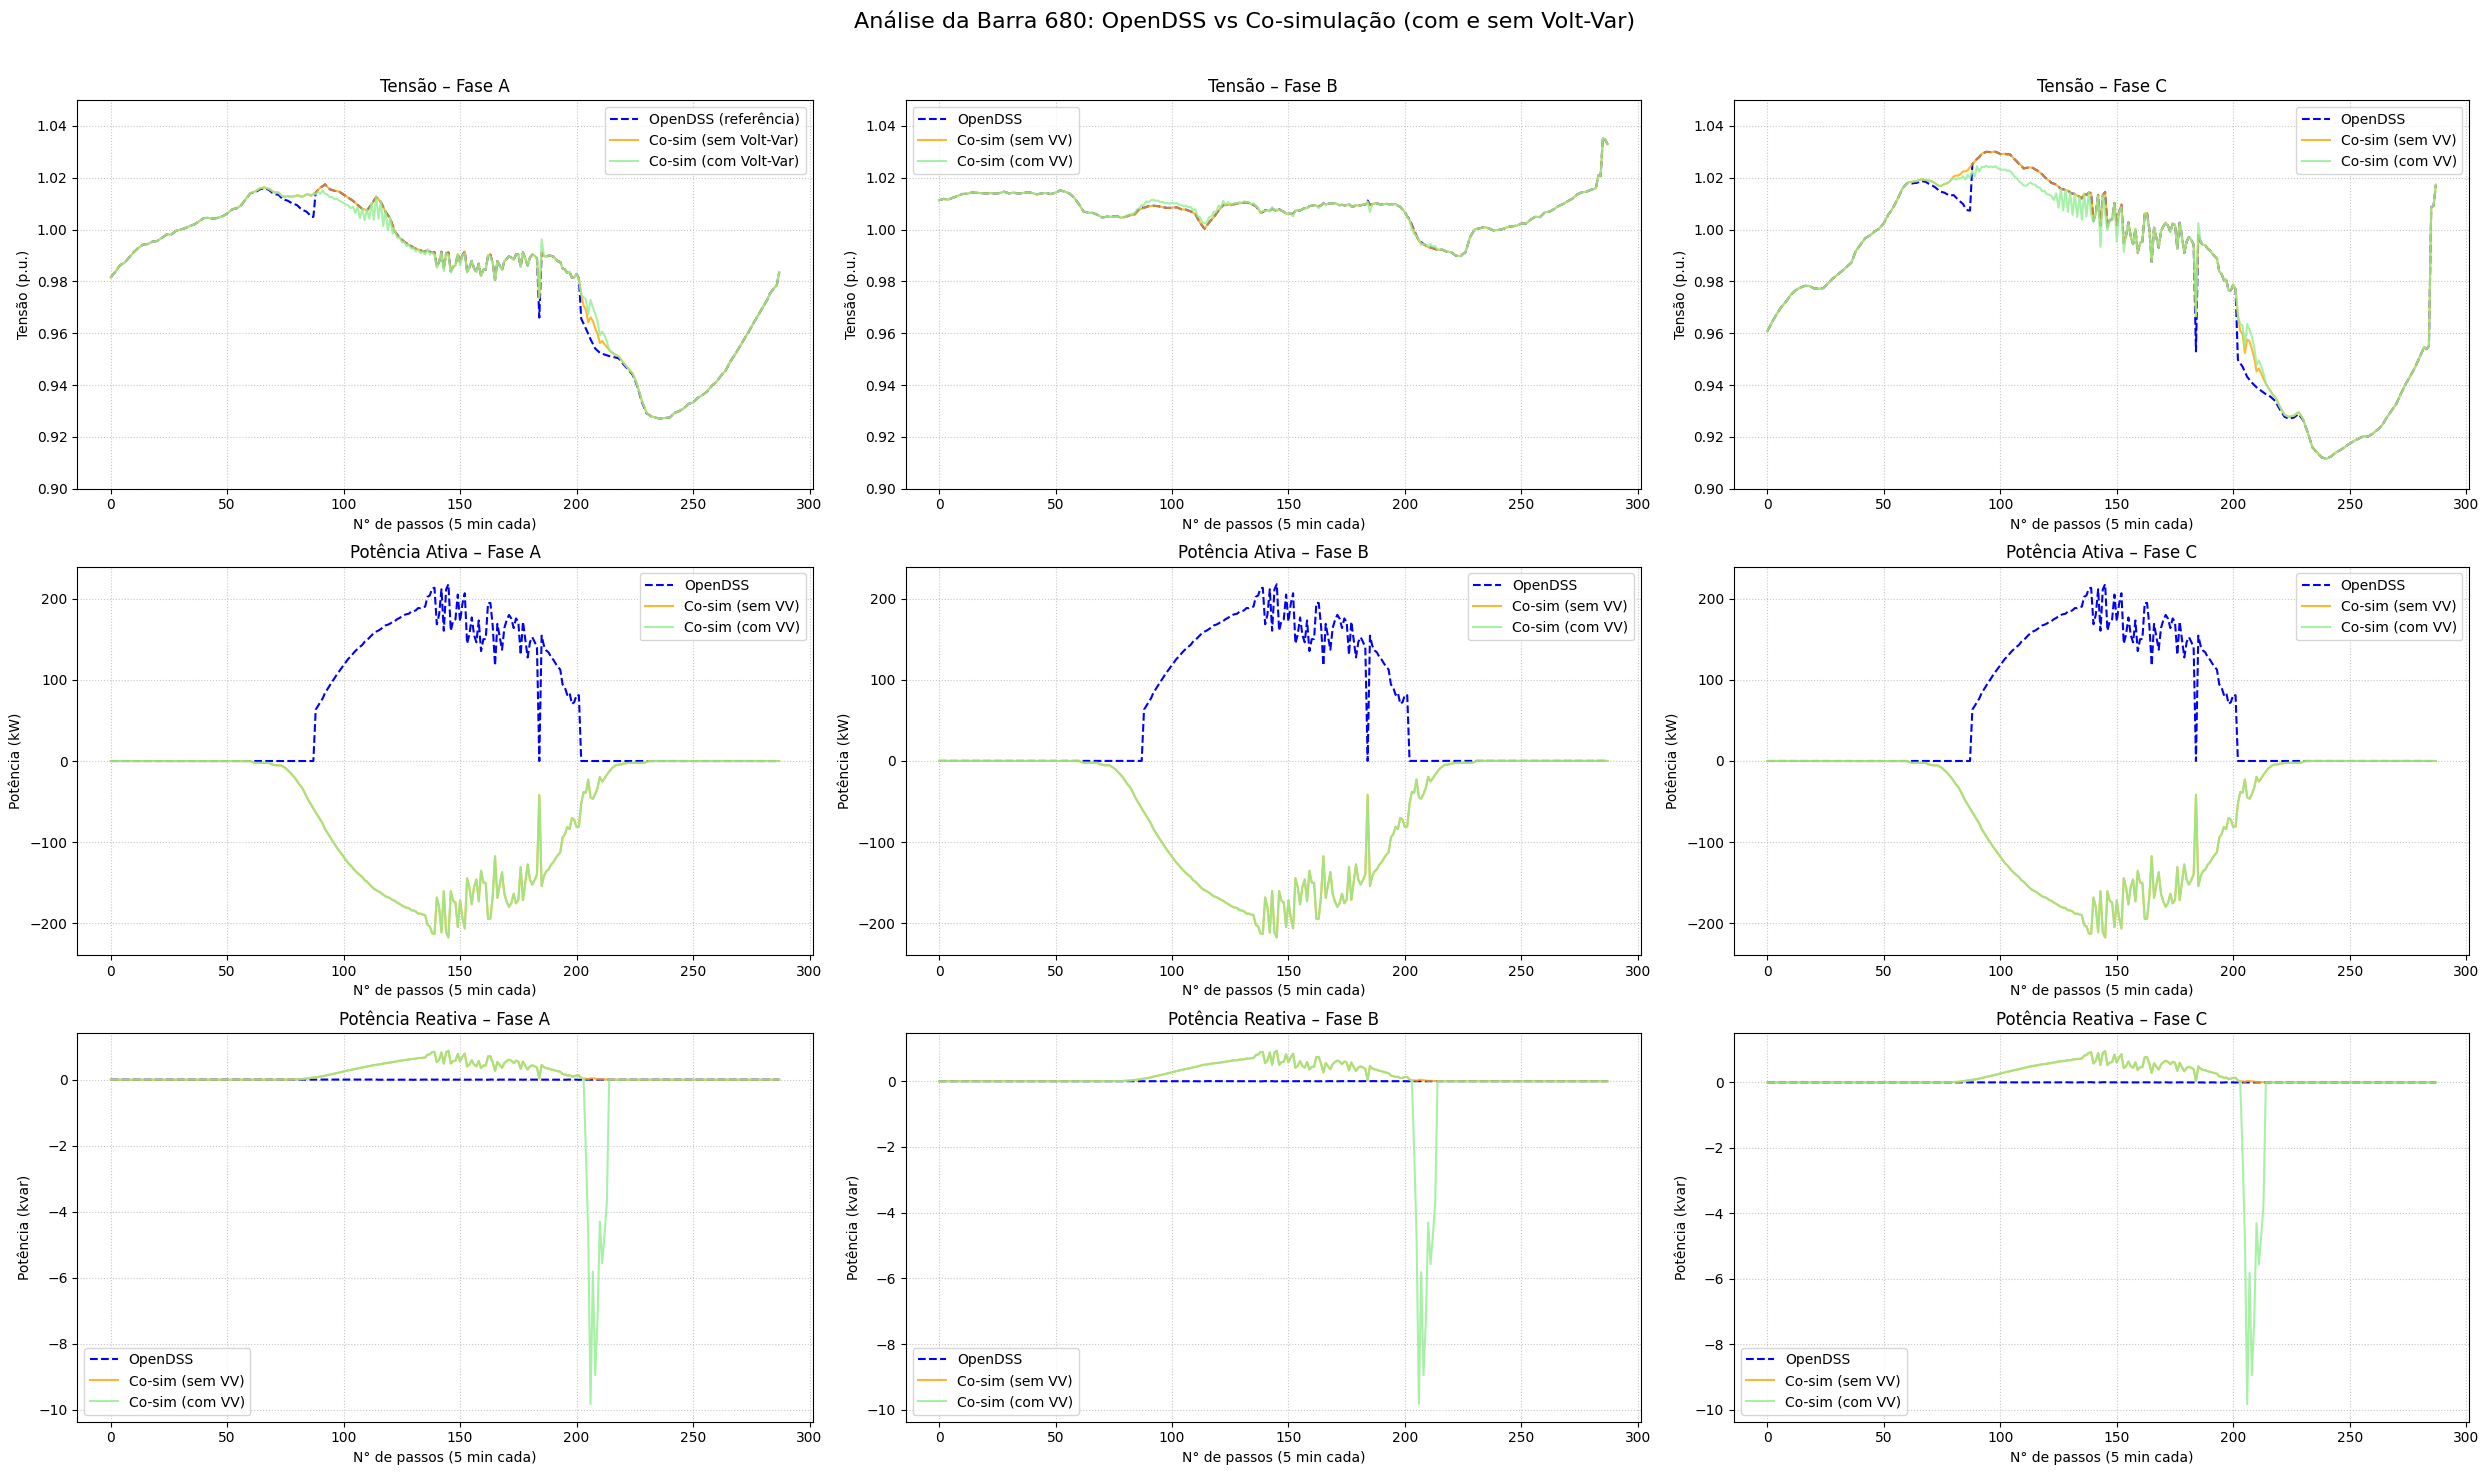

In [26]:
# Eixo x (número de passos de 5 min)
passos = range(len(bus680_va_pv))

# Cria figura 3x3 (3 grandezas x 3 fases)
fig, axs = plt.subplots(3, 3, figsize=(25, 15))
fig.suptitle('Análise da Barra 680: OpenDSS vs Co-simulação (com e sem Volt-Var)', fontsize=16)

# ==================== LINHA 0 – TENSÃO (pu) ====================
# Fase A
axs[0, 0].plot(passos, bus680_va_pv, label='OpenDSS (referência)', color='blue', linestyle='--')
axs[0, 0].plot(passos, bus680_va_pv_cosim, label='Co-sim (sem Volt-Var)', color='orange', alpha=0.8)
axs[0, 0].plot(passos, bus680_va_pv_voltvar, label='Co-sim (com Volt-Var)', color='lightgreen', alpha=0.8)
axs[0, 0].set_title('Tensão – Fase A')
axs[0, 0].set_ylabel('Tensão (p.u.)')
axs[0, 0].set_xlabel('N° de passos (5 min cada)')
axs[0, 0].grid(True, linestyle=':', alpha=0.7)
axs[0, 0].legend()
axs[0, 0].set_ylim(0.90, 1.05)

# Fase B
axs[0, 1].plot(passos, bus680_vb_pv, label='OpenDSS', color='blue', linestyle='--')
axs[0, 1].plot(passos, bus680_vb_pv_cosim, label='Co-sim (sem VV)', color='orange', alpha=0.8)
axs[0, 1].plot(passos, bus680_vb_pv_voltvar, label='Co-sim (com VV)', color='lightgreen', alpha=0.8)
axs[0, 1].set_title('Tensão – Fase B')
axs[0, 1].set_ylabel('Tensão (p.u.)')
axs[0, 1].set_xlabel('N° de passos (5 min cada)')
axs[0, 1].grid(True, linestyle=':', alpha=0.7)
axs[0, 1].legend()
axs[0, 1].set_ylim(0.90, 1.05)

# Fase C
axs[0, 2].plot(passos, bus680_vc_pv, label='OpenDSS', color='blue', linestyle='--')
axs[0, 2].plot(passos, bus680_vc_pv_cosim, label='Co-sim (sem VV)', color='orange', alpha=0.8)
axs[0, 2].plot(passos, bus680_vc_pv_voltvar, label='Co-sim (com VV)', color='lightgreen', alpha=0.8)
axs[0, 2].set_title('Tensão – Fase C')
axs[0, 2].set_ylabel('Tensão (p.u.)')
axs[0, 2].set_xlabel('N° de passos (5 min cada)')
axs[0, 2].grid(True, linestyle=':', alpha=0.7)
axs[0, 2].legend()
axs[0, 2].set_ylim(0.90, 1.05)

# ==================== LINHA 1 – POTÊNCIA ATIVA (kW) ====================
# Fase A
axs[1, 0].plot(passos, bus680_pa_pv, label='OpenDSS', color='blue', linestyle='--')
axs[1, 0].plot(passos, bus680_pa_pv_cosim, label='Co-sim (sem VV)', color='orange', alpha=0.8)
axs[1, 0].plot(passos, bus680_pa_pv_voltvar, label='Co-sim (com VV)', color='lightgreen', alpha=0.8)
axs[1, 0].set_title('Potência Ativa – Fase A')
axs[1, 0].set_ylabel('Potência (kW)')
axs[1, 0].set_xlabel('N° de passos (5 min cada)')
axs[1, 0].grid(True, linestyle=':', alpha=0.7)
axs[1, 0].legend()

# Fase B
axs[1, 1].plot(passos, bus680_pb_pv, label='OpenDSS', color='blue', linestyle='--')
axs[1, 1].plot(passos, bus680_pb_pv_cosim, label='Co-sim (sem VV)', color='orange', alpha=0.8)
axs[1, 1].plot(passos, bus680_pb_pv_voltvar, label='Co-sim (com VV)', color='lightgreen', alpha=0.8)
axs[1, 1].set_title('Potência Ativa – Fase B')
axs[1, 1].set_ylabel('Potência (kW)')
axs[1, 1].set_xlabel('N° de passos (5 min cada)')
axs[1, 1].grid(True, linestyle=':', alpha=0.7)
axs[1, 1].legend()

# Fase C
axs[1, 2].plot(passos, bus680_pc_pv, label='OpenDSS', color='blue', linestyle='--')
axs[1, 2].plot(passos, bus680_pc_pv_cosim, label='Co-sim (sem VV)', color='orange', alpha=0.8)
axs[1, 2].plot(passos, bus680_pc_pv_voltvar, label='Co-sim (com VV)', color='lightgreen', alpha=0.8)
axs[1, 2].set_title('Potência Ativa – Fase C')
axs[1, 2].set_ylabel('Potência (kW)')
axs[1, 2].set_xlabel('N° de passos (5 min cada)')
axs[1, 2].grid(True, linestyle=':', alpha=0.7)
axs[1, 2].legend()

# ==================== LINHA 2 – POTÊNCIA REATIVA (kvar) ====================
# Fase A
axs[2, 0].plot(passos, bus680_qa_pv, label='OpenDSS', color='blue', linestyle='--')
axs[2, 0].plot(passos, bus680_qa_pv_cosim, label='Co-sim (sem VV)', color='orange', alpha=0.8)
axs[2, 0].plot(passos, bus680_qa_pv_voltvar, label='Co-sim (com VV)', color='lightgreen', alpha=0.8)
axs[2, 0].set_title('Potência Reativa – Fase A')
axs[2, 0].set_ylabel('Potência (kvar)')
axs[2, 0].set_xlabel('N° de passos (5 min cada)')
axs[2, 0].grid(True, linestyle=':', alpha=0.7)
axs[2, 0].legend()

# Fase B
axs[2, 1].plot(passos, bus680_qb_pv, label='OpenDSS', color='blue', linestyle='--')
axs[2, 1].plot(passos, bus680_qb_pv_cosim, label='Co-sim (sem VV)', color='orange', alpha=0.8)
axs[2, 1].plot(passos, bus680_qb_pv_voltvar, label='Co-sim (com VV)', color='lightgreen', alpha=0.8)
axs[2, 1].set_title('Potência Reativa – Fase B')
axs[2, 1].set_ylabel('Potência (kvar)')
axs[2, 1].set_xlabel('N° de passos (5 min cada)')
axs[2, 1].grid(True, linestyle=':', alpha=0.7)
axs[2, 1].legend()

# Fase C
axs[2, 2].plot(passos, bus680_qc_pv, label='OpenDSS', color='blue', linestyle='--')
axs[2, 2].plot(passos, bus680_qc_pv_cosim, label='Co-sim (sem VV)', color='orange', alpha=0.8)
axs[2, 2].plot(passos, bus680_qc_pv_voltvar, label='Co-sim (com VV)', color='lightgreen', alpha=0.8)
axs[2, 2].set_title('Potência Reativa – Fase C')
axs[2, 2].set_ylabel('Potência (kvar)')
axs[2, 2].set_xlabel('N° de passos (5 min cada)')
axs[2, 2].grid(True, linestyle=':', alpha=0.7)
axs[2, 2].legend()

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

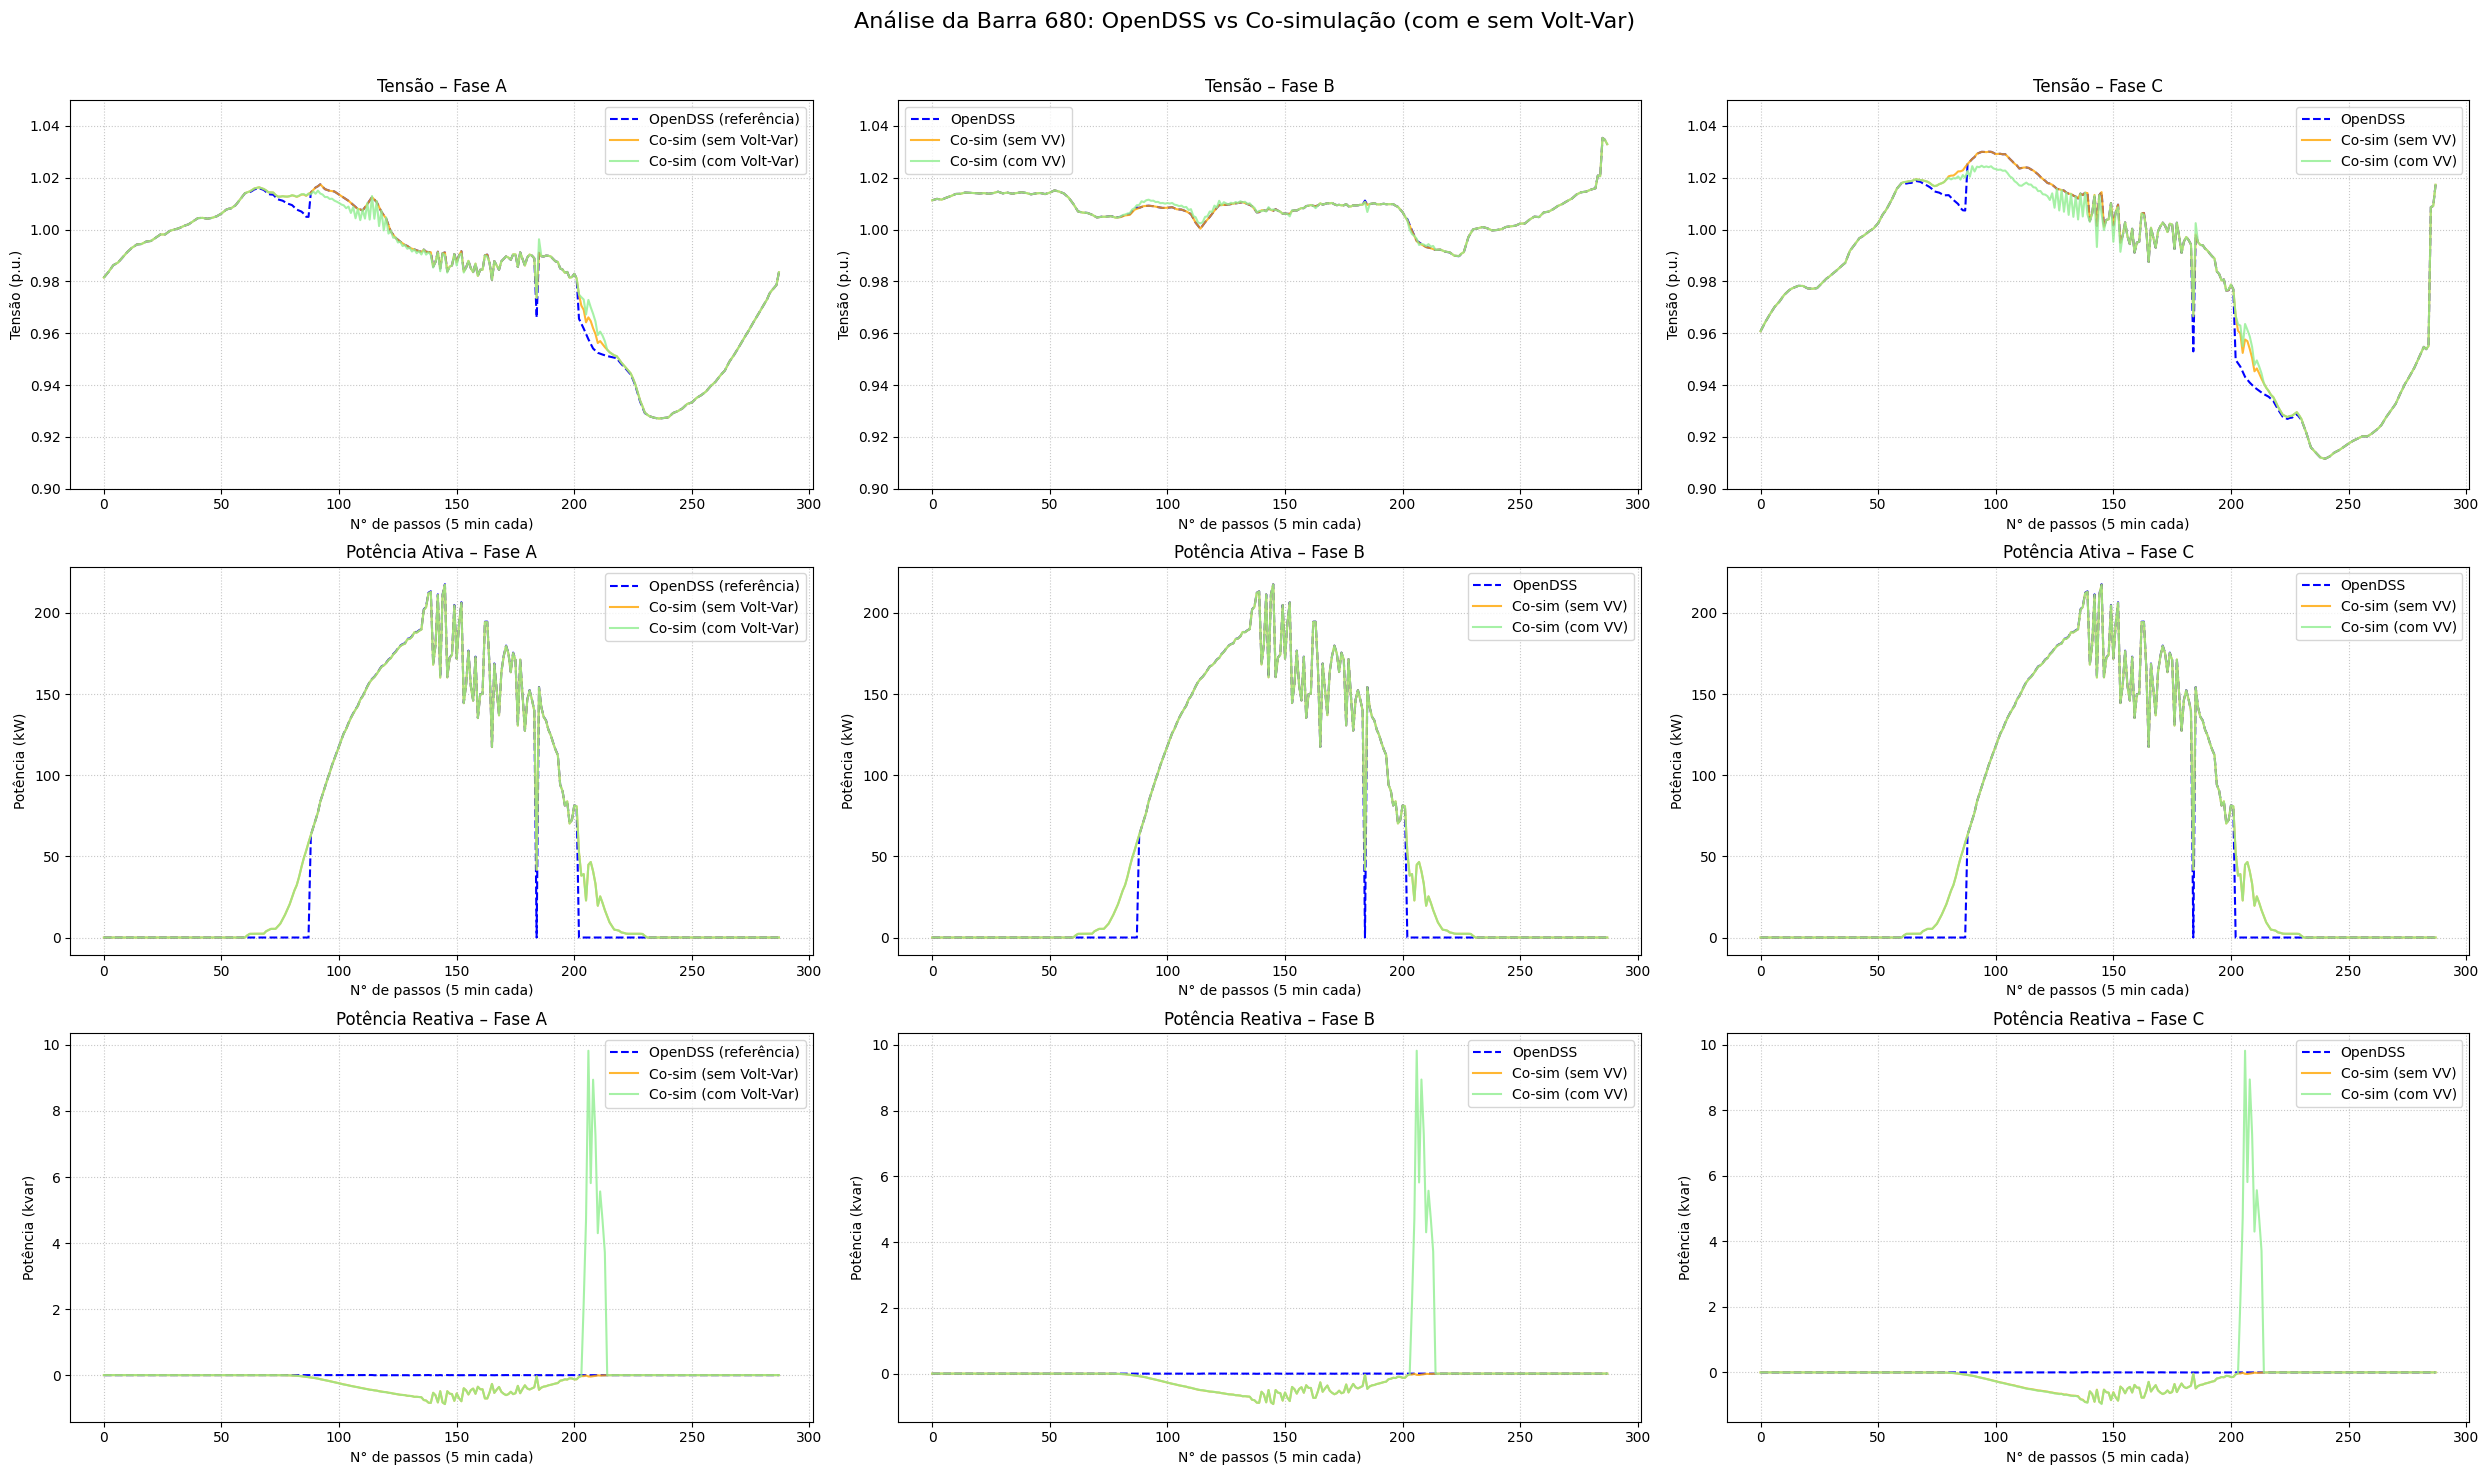

In [33]:
# Eixo x (número de passos de 5 min)
passos = range(len(bus680_va_pv))

# Cria figura 3x3 (3 grandezas x 3 fases)
fig, axs = plt.subplots(3, 3, figsize=(25, 15))
fig.suptitle('Análise da Barra 680: OpenDSS vs Co-simulação (com e sem Volt-Var)', fontsize=16)

# ==================== LINHA 0 – TENSÃO (pu) ====================
# Fase A
axs[0, 0].plot(passos, bus680_va_pv, label='OpenDSS (referência)', color='blue', linestyle='--')
axs[0, 0].plot(passos, bus680_va_pv_cosim, label='Co-sim (sem Volt-Var)', color='orange', alpha=0.8)
axs[0, 0].plot(passos, bus680_va_pv_voltvar, label='Co-sim (com Volt-Var)', color='lightgreen', alpha=0.8)
axs[0, 0].set_title('Tensão – Fase A')
axs[0, 0].set_ylabel('Tensão (p.u.)')
axs[0, 0].set_xlabel('N° de passos (5 min cada)')
axs[0, 0].grid(True, linestyle=':', alpha=0.7)
axs[0, 0].legend()
axs[0, 0].set_ylim(0.90, 1.05)

# Fase B
axs[0, 1].plot(passos, bus680_vb_pv, label='OpenDSS', color='blue', linestyle='--')
axs[0, 1].plot(passos, bus680_vb_pv_cosim, label='Co-sim (sem VV)', color='orange', alpha=0.8)
axs[0, 1].plot(passos, bus680_vb_pv_voltvar, label='Co-sim (com VV)', color='lightgreen', alpha=0.8)
axs[0, 1].set_title('Tensão – Fase B')
axs[0, 1].set_ylabel('Tensão (p.u.)')
axs[0, 1].set_xlabel('N° de passos (5 min cada)')
axs[0, 1].grid(True, linestyle=':', alpha=0.7)
axs[0, 1].legend()
axs[0, 1].set_ylim(0.90, 1.05)

# Fase C
axs[0, 2].plot(passos, bus680_vc_pv, label='OpenDSS', color='blue', linestyle='--')
axs[0, 2].plot(passos, bus680_vc_pv_cosim, label='Co-sim (sem VV)', color='orange', alpha=0.8)
axs[0, 2].plot(passos, bus680_vc_pv_voltvar, label='Co-sim (com VV)', color='lightgreen', alpha=0.8)
axs[0, 2].set_title('Tensão – Fase C')
axs[0, 2].set_ylabel('Tensão (p.u.)')
axs[0, 2].set_xlabel('N° de passos (5 min cada)')
axs[0, 2].grid(True, linestyle=':', alpha=0.7)
axs[0, 2].legend()
axs[0, 2].set_ylim(0.90, 1.05)

# ==================== LINHA 1 – POTÊNCIA ATIVA (kW) ====================
# Fase A
axs[1, 0].plot(passos, bus680_pa_pv, label='OpenDSS (referência)', color='blue', linestyle='--')
axs[1, 0].plot(passos, [-p for p in bus680_pa_pv_cosim], label='Co-sim (sem Volt-Var)', color='orange', alpha=0.8)
axs[1, 0].plot(passos, [-p for p in bus680_pa_pv_voltvar], label='Co-sim (com Volt-Var)', color='lightgreen', alpha=0.8)
axs[1, 0].set_title('Potência Ativa – Fase A')
axs[1, 0].set_ylabel('Potência (kW)')
axs[1, 0].set_xlabel('N° de passos (5 min cada)')
axs[1, 0].grid(True, linestyle=':', alpha=0.7)
axs[1, 0].legend()

# Fase B
axs[1, 1].plot(passos, bus680_pb_pv, label='OpenDSS', color='blue', linestyle='--')
axs[1, 1].plot(passos, [-p for p in bus680_pb_pv_cosim], label='Co-sim (sem VV)', color='orange', alpha=0.8)
axs[1, 1].plot(passos, [-p for p in bus680_pb_pv_voltvar], label='Co-sim (com VV)', color='lightgreen', alpha=0.8)
axs[1, 1].set_title('Potência Ativa – Fase B')
axs[1, 1].set_ylabel('Potência (kW)')
axs[1, 1].set_xlabel('N° de passos (5 min cada)')
axs[1, 1].grid(True, linestyle=':', alpha=0.7)
axs[1, 1].legend()

# Fase C
axs[1, 2].plot(passos, bus680_pc_pv, label='OpenDSS', color='blue', linestyle='--')
axs[1, 2].plot(passos, [-p for p in bus680_pc_pv_cosim], label='Co-sim (sem VV)', color='orange', alpha=0.8)
axs[1, 2].plot(passos, [-p for p in bus680_pc_pv_voltvar], label='Co-sim (com VV)', color='lightgreen', alpha=0.8)
axs[1, 2].set_title('Potência Ativa – Fase C')
axs[1, 2].set_ylabel('Potência (kW)')
axs[1, 2].set_xlabel('N° de passos (5 min cada)')
axs[1, 2].grid(True, linestyle=':', alpha=0.7)
axs[1, 2].legend()

# ==================== LINHA 2 – POTÊNCIA REATIVA (kvar) ====================
# Fase A
axs[2, 0].plot(passos, bus680_qa_pv, label='OpenDSS (referência)', color='blue', linestyle='--')
axs[2, 0].plot(passos, [-q for q in bus680_qa_pv_cosim], label='Co-sim (sem Volt-Var)', color='orange', alpha=0.8)
axs[2, 0].plot(passos, [-q for q in bus680_qa_pv_voltvar], label='Co-sim (com Volt-Var)', color='lightgreen', alpha=0.8)
axs[2, 0].set_title('Potência Reativa – Fase A')
axs[2, 0].set_ylabel('Potência (kvar)')
axs[2, 0].set_xlabel('N° de passos (5 min cada)')
axs[2, 0].grid(True, linestyle=':', alpha=0.7)
axs[2, 0].legend()

# Fase B
axs[2, 1].plot(passos, bus680_qb_pv, label='OpenDSS', color='blue', linestyle='--')
axs[2, 1].plot(passos, [-q for q in bus680_qb_pv_cosim], label='Co-sim (sem VV)', color='orange', alpha=0.8)
axs[2, 1].plot(passos, [-q for q in bus680_qb_pv_voltvar], label='Co-sim (com VV)', color='lightgreen', alpha=0.8)
axs[2, 1].set_title('Potência Reativa – Fase B')
axs[2, 1].set_ylabel('Potência (kvar)')
axs[2, 1].set_xlabel('N° de passos (5 min cada)')
axs[2, 1].grid(True, linestyle=':', alpha=0.7)
axs[2, 1].legend()

# Fase C
axs[2, 2].plot(passos, bus680_qc_pv, label='OpenDSS', color='blue', linestyle='--')
axs[2, 2].plot(passos, [-q for q in bus680_qc_pv_cosim], label='Co-sim (sem VV)', color='orange', alpha=0.8)
axs[2, 2].plot(passos, [-q for q in bus680_qc_pv_voltvar], label='Co-sim (com VV)', color='lightgreen', alpha=0.8)
axs[2, 2].set_title('Potência Reativa – Fase C')
axs[2, 2].set_ylabel('Potência (kvar)')
axs[2, 2].set_xlabel('N° de passos (5 min cada)')
axs[2, 2].grid(True, linestyle=':', alpha=0.7)
axs[2, 2].legend()

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

In [34]:
# ==============================================================================
# ALGORITMO DE CÁLCULO DE MÉTRICAS DE ERRO (PURO PYTHON)
# ==============================================================================

def calcular_metricas_erro(lista_referencia, lista_medicao, amostral=True):
    """
    Calcula RMSE, MAE, desvio padrão dos erros e erro médio entre duas listas.
    
    Parâmetros:
    - lista_referencia: Valores do OpenDSS puro (Ground Truth).
    - lista_medicao: Valores da Co-simulação no Mosaik (já corrigidos).
    - amostral: Se True, usa desvio padrão amostral (divisão por n-1).
    
    Retorna: rmse, mae, desvio_padrao_erros, erro_medio
    """
    ref = list(lista_referencia)
    med = list(lista_medicao)
    
    tamanho = min(len(ref), len(med))
    if tamanho == 0:
        return None, None, None, None
    
    erros = []
    soma_erros_quadrados = 0.0
    soma_erros_absolutos = 0.0
    soma_erros = 0.0
    
    for i in range(tamanho):
        erro = ref[i] - med[i]
        erros.append(erro)
        soma_erros_quadrados += erro ** 2
        soma_erros_absolutos += abs(erro)
        soma_erros += erro
    
    mse = soma_erros_quadrados / tamanho
    rmse = mse ** 0.5
    mae = soma_erros_absolutos / tamanho
    erro_medio = soma_erros / tamanho
    
    if amostral and tamanho > 1:
        divisor = tamanho - 1
    else:
        divisor = tamanho
    
    variancia = sum((e - erro_medio) ** 2 for e in erros) / divisor
    desvio_padrao_erros = variancia ** 0.5
    
    return rmse, mae, desvio_padrao_erros, erro_medio


# ==============================================================================
# MAPEAMENTO DAS CURVAS – BARRA 680 (SOMENTE SEM VOLT‑VAR, COM INVERSÃO EM P E Q)
# ==============================================================================

comparacoes_sem_vv = {
    # Tensões (sem inversão)
    "Tensão Barra 680 - Fase A [pu]": (bus680_va_pv, bus680_va_pv_cosim),
    "Tensão Barra 680 - Fase B [pu]": (bus680_vb_pv, bus680_vb_pv_cosim),
    "Tensão Barra 680 - Fase C [pu]": (bus680_vc_pv, bus680_vc_pv_cosim),
    
    # Potência Ativa (com inversão de sinal)
    "Potência Ativa Barra 680 - Fase A [kW]": (bus680_pa_pv, [-p for p in bus680_pa_pv_cosim]),
    "Potência Ativa Barra 680 - Fase B [kW]": (bus680_pb_pv, [-p for p in bus680_pb_pv_cosim]),
    "Potência Ativa Barra 680 - Fase C [kW]": (bus680_pc_pv, [-p for p in bus680_pc_pv_cosim]),
    
    # Potência Reativa (com inversão de sinal)
    "Potência Reativa Barra 680 - Fase A [kvar]": (bus680_qa_pv, [-q for q in bus680_qa_pv_cosim]),
    "Potência Reativa Barra 680 - Fase B [kvar]": (bus680_qb_pv, [-q for q in bus680_qb_pv_cosim]),
    "Potência Reativa Barra 680 - Fase C [kvar]": (bus680_qc_pv, [-q for q in bus680_qc_pv_cosim]),
}


# ==============================================================================
# EXECUÇÃO E RELATÓRIO – SOMENTE SEM VOLT‑VAR
# ==============================================================================
print("="*100)
print(f"{'RELATÓRIO DE ERROS (SEM VOLT‑VAR): OPENDSS vs CO‑SIMULAÇÃO (BASE)':^100}")
print("="*100)
print(f"{'Grandeza Analisada':<50} | {'RMSE':<12} | {'MAE':<12} | {'Desv.Padrão':<12} | {'Erro Médio':<12}")
print("-" * 100)

for nome_grandeza, (curva_ref, curva_med) in comparacoes_sem_vv.items():
    rmse, mae, desvio_padrao, erro_medio = calcular_metricas_erro(curva_ref, curva_med, amostral=True)
    if rmse is not None:
        print(f"{nome_grandeza:<50} | {rmse:<12.6f} | {mae:<12.6f} | {desvio_padrao:<12.6f} | {erro_medio:<12.6f}")
    else:
        print(f"{nome_grandeza:<50} | {'ERRO':<12} | {'ERRO':<12} | {'ERRO':<12} | {'ERRO':<12}")

print("="*100)

# ==============================================================================
# INTERPRETAÇÃO DOS RESULTADOS
# ==============================================================================
print("\n🔍 Interpretação das métricas:")
print("- RMSE (Root Mean Square Error): penaliza erros grandes (sensível a outliers).")
print("- MAE (Mean Absolute Error): magnitude média do erro (mesma unidade da grandeza).")
print("- Desvio Padrão dos Erros: mede a dispersão dos erros em torno do erro médio.")
print("  * Desvio pequeno → erros consistentes, pouca variabilidade.")
print("  * Desvio grande → erros variam muito ao longo do tempo.")
print("- Erro Médio: indica viés sistemático (positivo = superestimativa, negativo = subestimativa).")

                 RELATÓRIO DE ERROS (SEM VOLT‑VAR): OPENDSS vs CO‑SIMULAÇÃO (BASE)                  
Grandeza Analisada                                 | RMSE         | MAE          | Desv.Padrão  | Erro Médio  
----------------------------------------------------------------------------------------------------
Tensão Barra 680 - Fase A [pu]                     | 0.001824     | 0.000570     | 0.001737     | -0.000568   
Tensão Barra 680 - Fase B [pu]                     | 0.000071     | 0.000022     | 0.000069     | 0.000015    
Tensão Barra 680 - Fase C [pu]                     | 0.003281     | 0.001025     | 0.003123     | -0.001022   
Potência Ativa Barra 680 - Fase A [kW]             | 10.691607    | 3.412425     | 10.202496    | -3.252841   
Potência Ativa Barra 680 - Fase B [kW]             | 10.693687    | 3.357367     | 10.186423    | -3.309384   
Potência Ativa Barra 680 - Fase C [kW]             | 10.691686    | 3.398085     | 10.197921    | -3.267362   
Potência Reativa Barr